### Prerequsite - Upgrade Scikit Learn
The current workspace has scikit-learn v0.19.1 installed. However, you can upgrade scikit-learn to 0.24.x. and use this [OneHotEncoder](https://scikit-learn.org/0.21/modules/generated/sklearn.preprocessing.OneHotEncoder.html) library. 


In [1]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 0.19.1.


In [2]:
import os
os.environ['PATH'] = f"{os.environ['PATH']}:/root/.local/bin"

Restart Kernel

In [3]:
#!python -m pip install --upgrade scikit-learn
#import sklearn
#print('The scikit-learn version is {}.'.format(sklearn.__version__))

In [4]:
# Now you can import and use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
# your code goes here

In [5]:
# Similarly, should you need any other package, they can install it as:
!python -m pip install 'tensorflow-tensorboard<0.2.0,>=0.1.0'

    100% |████████████████████████████████| 1.6MB 12.2MB/s ta 0:00:01


# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [6]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# magic word for producing visualizations in notebook
%matplotlib inline

'''
Import note: The classroom currently uses sklearn version 0.19.
If you need to use an imputer, it is available in sklearn.preprocessing.Imputer,
instead of sklearn.impute as in newer versions of sklearn.
'''
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [7]:
# Loads in the general demographics data.
raw_gen_demo = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')
# Loads in the feature summary file.
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

In [8]:
# Checks the structure of the main data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).
rows, cols = raw_gen_demo.shape
print (f'This is the number of rows in the main dataset: {rows} \nThis is the number of columns in the main dataset: {cols}\nThese are the first few rows in the main dataset:')
raw_gen_demo.head(5)

This is the number of rows in the main dataset: 891221 
This is the number of columns in the main dataset: 85
These are the first few rows in the main dataset:


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [9]:
# Checks the structure of the feature summary data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).
rows, cols = feat_info.shape
print (f'This is the number of rows in the feature info dataset: {rows} \nThis is the number of columns in the feature info dataset: {cols}\nThese are the first few rows in the feature info dataset:')
feat_info.head(5)

This is the number of rows in the feature info dataset: 85 
This is the number of columns in the feature info dataset: 4
These are the first few rows in the feature info dataset:


,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [10]:
# Grabs the column that contains the values we need
# and parses it to make it into a collection of lists
miss_vals = feat_info['missing_or_unknown']
miss_vals[0]
parse_vals = []
# These lines ensure the values X and XX are read as
# strings instead of variables
X = 'X'
XX = 'XX'

for vals in miss_vals:
    val = eval(vals)
    parse_vals.append(val)

In [11]:
# Creates a copy of the raw data
gen_demo = raw_gen_demo.copy()

# Creates a loop to replace values in our dataset
# that match any value in our list from before 
# that were marked for conversion in NaNs in the same index
idx=0
for vals in parse_vals:
    for val in vals:
        gen_demo.iloc[:,idx].replace(val, np.nan, inplace=True)
    idx+=1

In [12]:
# Checks the df after transformation
gen_demo.head(5)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,NaN,2.0,1,2.0,3,4,3,5,5,3,4,NaN,10.0,0,NaN,15.0,4.0,2.0,2.0,1.0,1.0,NaN,NaN,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1.0,2,5.0,1,5,2,5,4,5,1,1996.0,10.0,0,3.0,21.0,6.0,5.0,3.0,2.0,1.0,1.0,14.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,1.0,NaN,2.0,5,NaN,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,NaN,3.0,2,3.0,1,4,1,2,3,5,1,1979.0,10.0,1,3.0,3.0,1.0,1.0,1.0,3.0,2.0,1.0,15.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,0.0,NaN,1.0,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,NaN,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2.0,4.0,2,2.0,4,2,5,2,1,2,6,1957.0,1.0,0,2.0,NaN,NaN,NaN,NaN,9.0,4.0,1.0,8.0,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,0.0,NaN,1.0,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,NaN,3.0,1,5.0,4,3,4,1,3,2,5,1963.0,5.0,0,3.0,32.0,10.0,10.0,5.0,3.0,2.0,1.0,8.0,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,0.0,NaN,2.0,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,NaN,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [13]:
# Calculates the null value count for each column
nan_values = gen_demo.isnull().sum()
# Calculates the null value percentage for each column
percent_nan_values = (nan_values / gen_demo.shape[0]) * 100

In [14]:
# Sorts the percentages in ascending value
percent_nan_values.sort_values(inplace=True)
percent_nan_values

ZABEOTYP                  0.000000
SEMIO_TRADV               0.000000
SEMIO_PFLICHT             0.000000
SEMIO_KAEM                0.000000
SEMIO_DOM                 0.000000
SEMIO_KRIT                0.000000
SEMIO_RAT                 0.000000
SEMIO_KULT                0.000000
SEMIO_ERL                 0.000000
SEMIO_LUST                0.000000
SEMIO_VERT                0.000000
SEMIO_MAT                 0.000000
SEMIO_REL                 0.000000
SEMIO_SOZ                 0.000000
SEMIO_FAM                 0.000000
FINANZ_VORSORGER          0.000000
ANREDE_KZ                 0.000000
FINANZ_MINIMALIST         0.000000
FINANZ_SPARER             0.000000
FINANZ_ANLEGER            0.000000
FINANZ_UNAUFFAELLIGER     0.000000
FINANZ_HAUSBAUER          0.000000
GREEN_AVANTGARDE          0.000000
FINANZTYP                 0.000000
ALTERSKATEGORIE_GROB      0.323264
GFK_URLAUBERTYP           0.544646
LP_STATUS_GROB            0.544646
LP_STATUS_FEIN            0.544646
ONLINE_AFFINITAET   

Text(0.5,1,'Histogram of Percent of NaN values')

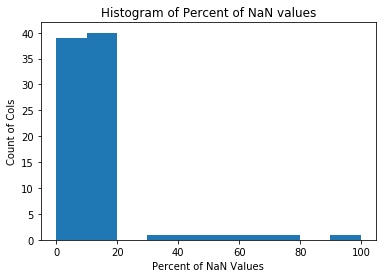

In [15]:
# Creates a histogram of Frequency of NaN values in cols
plt.hist(percent_nan_values)

plt.ylabel('Count of Cols')
plt.xlabel('Percent of NaN Values')
plt.title('Histogram of Percent of NaN values')

Text(0,0.5,'Column Names')

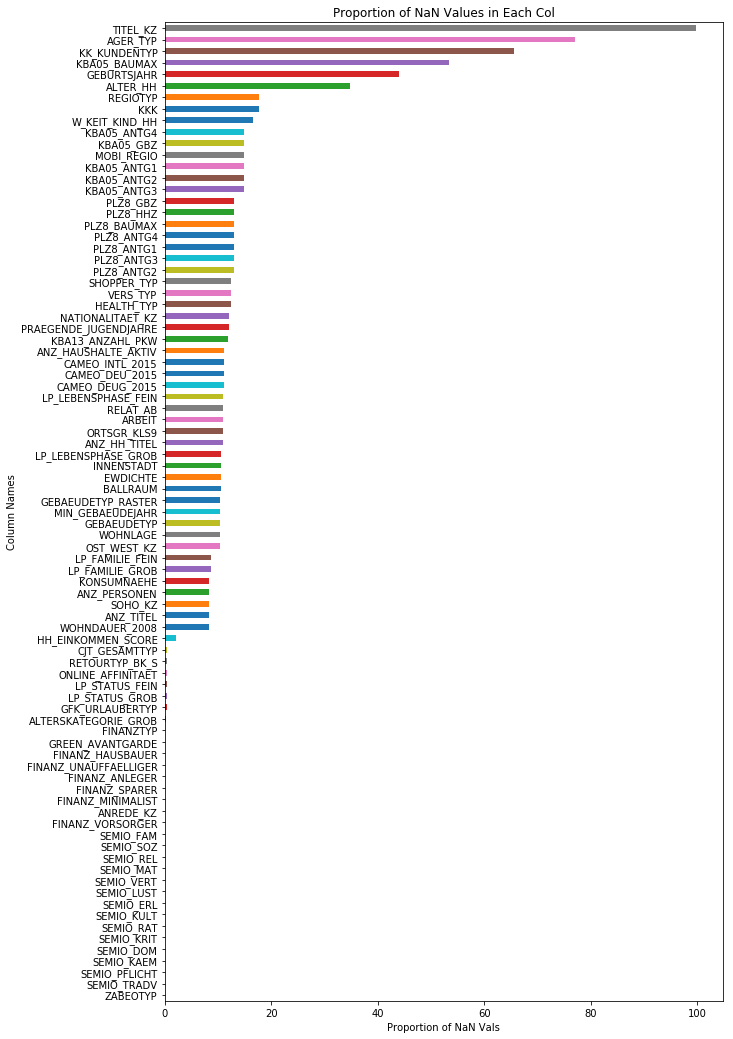

In [16]:
# Investigate patterns in the amount of missing data in each column.
ax = percent_nan_values.plot(kind='barh', figsize=(10,18),
                title='Proportion of NaN Values in Each Col')
ax.set_xlabel('Proportion of NaN Vals')
ax.set_ylabel('Column Names')

In [17]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)
percent_nan_values_gt20 = percent_nan_values[percent_nan_values>20]

outlier_cols = percent_nan_values_gt20.index
for col in outlier_cols:
    gen_demo.drop(col, axis=1, inplace=True)

In [18]:
print(f'Number of cols after dropping our outlier cols: {gen_demo.shape[1]}')

Number of cols after dropping our outlier cols: 79


#### Discussion 1.1.2: Assess Missing Data in Each Column
There were only a few columns with a large amount of missing values (greater than 18%) these were 'TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR' and 'ALTER_HH'; it seems like the columns that are already encoded (example:PLZ8_ANTG2, PLZ8_ANTG3, PLZ8_ANTG1, PLZ8_ANTG4, PLZ8_BAUMAX, PLZ8_HHZ and PLZ8_GBZ) all have the same/similar proportions so it seems like the original column, presumably PLZ8, had that proportion of missing data rather than losing data during encoding. It is also true for other columns that look like encoded columns such as the columns that start with: KBA05, SEMIO, FINANZ, and CAMEO. Overall, for the columns that are remaining and missing data, they are missing between 10-17% of their data.

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

In [19]:
# How much data is missing in each row of the dataset?
num_na_rows=gen_demo.isna().sum(axis=1)
num_na_rows.describe()

count    891221.000000
mean          5.649894
std          13.234687
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max          49.000000
dtype: float64

Text(0,0.5,'Frequency')

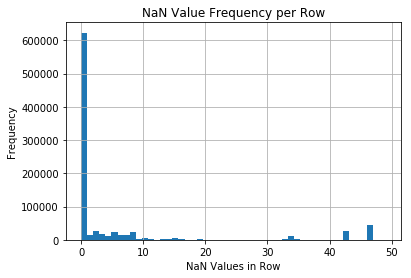

In [20]:
# Creates histogram of NaN values in rows
ax= num_na_rows.hist(bins=50)
ax.set_title('NaN Value Frequency per Row')
ax.set_xlabel('NaN Values in Row')
ax.set_ylabel('Frequency')

In [21]:
# Divides the datasets in half using the number of NaN values in each row
gen_demo_lt25 = gen_demo[num_na_rows <= 25]
gen_demo_gt25 = gen_demo[num_na_rows > 25]

I chose 25 as my arbitrary value as there is a clear seperation between 20 and 30, so chose the number in the middle, 25.

In [22]:
# Selects five columns with 0% NaN values
no_missing_cols = percent_nan_values[percent_nan_values==0].index
no_missing_cols_sub = no_missing_cols[:5]

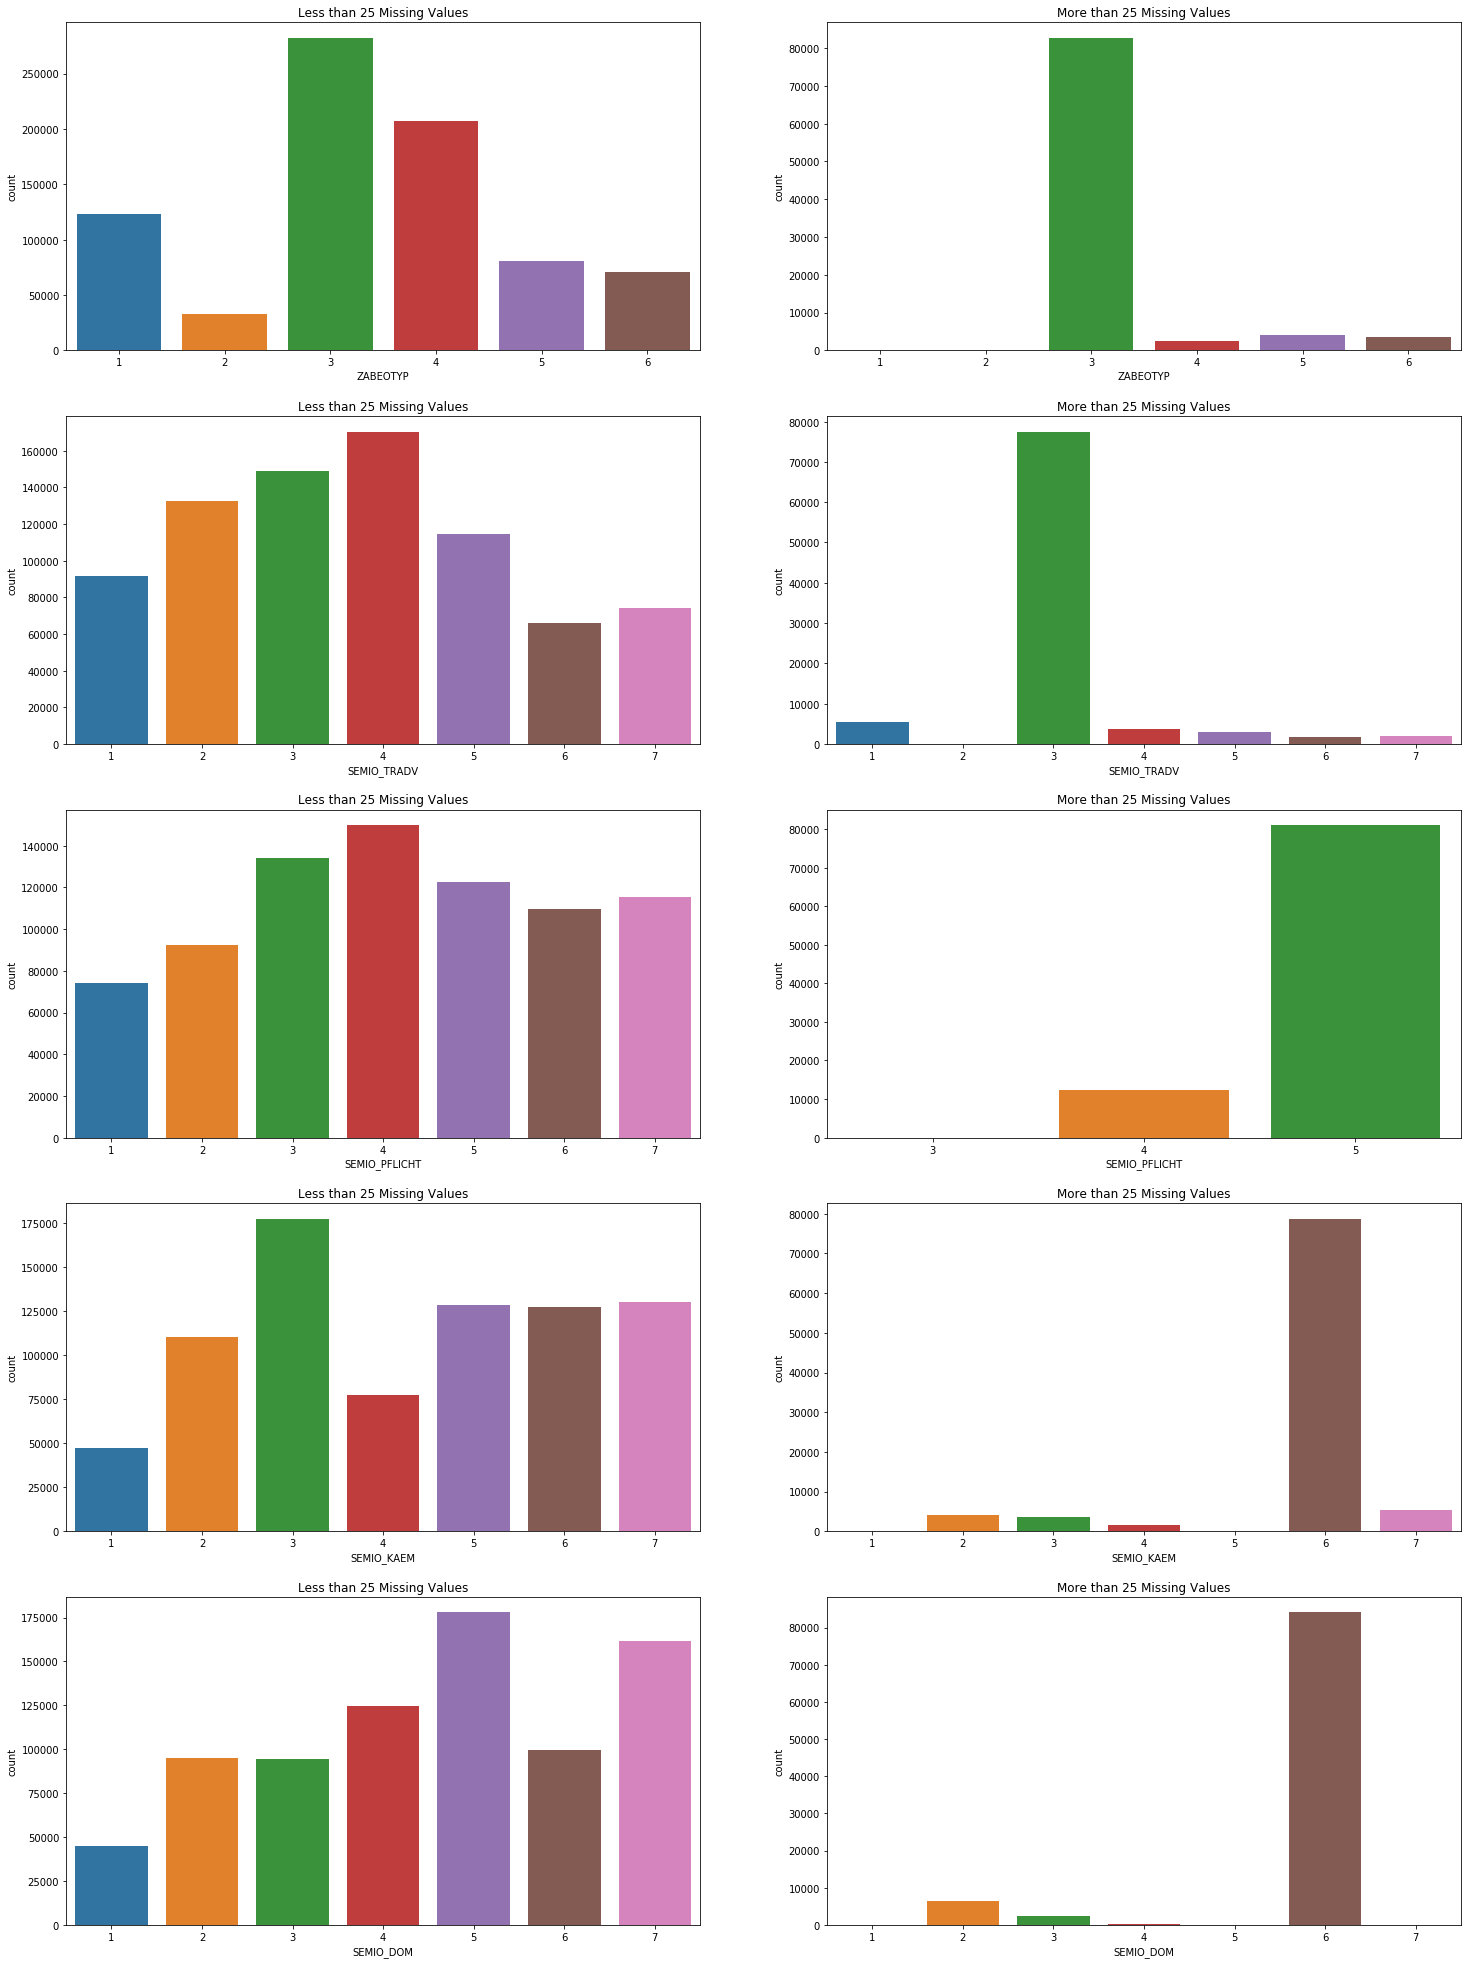

In [23]:
# Creates a plot containing the sub-countplots
fig, axes = plt.subplots(nrows=len(no_missing_cols_sub), ncols=2, figsize=(25,35))
for i in range(len(no_missing_cols_sub)):
    sns.countplot(gen_demo_lt25[no_missing_cols_sub[i]], ax=axes[i][0])
    axes[i][0].set_title('Less than 25 Missing Values')
    sns.countplot(gen_demo_gt25[no_missing_cols_sub[i]], ax=axes[i][1])
    axes[i][1].set_title('More than 25 Missing Values')

#### Discussion 1.1.3: Assess Missing Data in Each Row

The SEMIO columns in the left side all have similar distributions of missing values whereas the right side tends to have one column with a very large number (comparatively) of missing values, with the same being said for the first row of charts.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [24]:
# How many features are there of each data type?
features = gen_demo_lt25.columns
clean_feat_info = feat_info[feat_info['attribute'].isin(features)]
clean_feat_info['type'].value_counts()

ordinal        49
categorical    18
numeric         6
mixed           6
Name: type, dtype: int64

In [25]:
print(f'There are:\n49 ordinal columns\n18 categorical columns\n6 mixed columns\nand 6 numeric columns')

There are:
49 ordinal columns
18 categorical columns
6 mixed columns
and 6 numeric columns


#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [26]:
# Creates a df of categorical columns
cat_feats = clean_feat_info.query('type == "categorical"').attribute
cat_feats

2            ANREDE_KZ
3        CJT_GESAMTTYP
10           FINANZTYP
12     GFK_URLAUBERTYP
13    GREEN_AVANTGARDE
17     LP_FAMILIE_FEIN
18     LP_FAMILIE_GROB
19      LP_STATUS_FEIN
20      LP_STATUS_GROB
21    NATIONALITAET_KZ
38         SHOPPER_TYP
39             SOHO_KZ
41            VERS_TYP
42            ZABEOTYP
52         GEBAEUDETYP
55         OST_WEST_KZ
57     CAMEO_DEUG_2015
58      CAMEO_DEU_2015
Name: attribute, dtype: object

In [27]:
# Seperates our categorical columns by whether they are binary or multi-level
binary_feats = []
multi_feats = []
for feature in cat_feats:
    if len(gen_demo_lt25[feature].value_counts()) > 2:
        multi_feats.append(feature)
    elif len(gen_demo_lt25[feature].value_counts()) == 2:
        binary_feats.append(feature)

In [28]:
# Visually check which columns are binary
for feat in binary_feats:
    print(f'{feat}')
print('These are the binary categorical columns')

ANREDE_KZ
GREEN_AVANTGARDE
SOHO_KZ
VERS_TYP
OST_WEST_KZ
These are the binary categorical columns


In [29]:
# Visually check which columns are multi-level
for feat in multi_feats:
    print(f'{feat}')
print('These are the multi-level columns')

CJT_GESAMTTYP
FINANZTYP
GFK_URLAUBERTYP
LP_FAMILIE_FEIN
LP_FAMILIE_GROB
LP_STATUS_FEIN
LP_STATUS_GROB
NATIONALITAET_KZ
SHOPPER_TYP
ZABEOTYP
GEBAEUDETYP
CAMEO_DEUG_2015
CAMEO_DEU_2015
These are the multi-level columns


In [30]:
# Splits the binary columns based on whether they have decimal/numeric values or not
numeric_binfeat = []
notnum_binfeat = []
for feat in binary_feats:
    if gen_demo_lt25[feat].astype(str).str.contains(r'\d').any():
         numeric_binfeat.append(feat)
    else:
        notnum_binfeat.append(feat)

In [31]:
# Checks which column is our non-numeric binary column
print(f'This is the non-numeric binary categorical column: {notnum_binfeat}')

This is the non-numeric binary categorical column: ['OST_WEST_KZ']


In [32]:
# Checks the non-numeric values in the col
gen_demo_lt25['OST_WEST_KZ'].value_counts()

W    629433
O    168528
Name: OST_WEST_KZ, dtype: int64

In [33]:
# Creates a new df to hold our next changes
gen_demo_recoded = gen_demo_lt25.copy()

In [34]:
# Re-encodes the 'OST_WEST_KZ' column to have 1's and 0's
ost_kz_mapping = {'W':0,'O':1}
gen_demo_recoded['OST_WEST_KZ'].replace(ost_kz_mapping, inplace=True)

In [35]:
# Drops all of our multi-level categorical cols
for col in multi_feats:
    gen_demo_recoded.drop(col, axis=1, inplace=True)

In [36]:
print(f'Number of columns left: {gen_demo_recoded.shape[1]}')

Number of columns left: 66


#### Discussion 1.2.1: Re-Encode Categorical Features

The structure for the binary categorical columns are simple; however, while re-encoding the 'OST_WEST_KZ' column I found that the computational time to use pandas' get_dummies() was very very slow. With this information in mind I made the decision to **NOT** re-code the multi-level categorical columns as it would take a long time/large number of computational resources to re-code them, but to also use them in analysis later with ML.

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [37]:
# Fills NaN values with the mode of the column as mean takes longer
# and categorical data is 'more' accurate when filling with mode
# This will be needed later when doing pca; however, I will be using this to recode one of the columns
gen_demo_recoded = gen_demo_recoded.fillna(gen_demo_recoded.mode().iloc[0])

In [38]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.
gen_demo_recoded['PRAEGENDE_JUGENDJAHRE'].value_counts()

14.0    211677
8.0     141612
10.0     85800
5.0      84687
3.0      53841
15.0     42543
11.0     35751
9.0      33570
6.0      25652
12.0     24446
1.0      20678
4.0      20451
2.0       7479
13.0      5764
7.0       4010
Name: PRAEGENDE_JUGENDJAHRE, dtype: int64

In [39]:
# Creates a mapping to use to create a new column
movement_mapping = {
    1:0, 2:1,
    3:0, 4:1,
    5:0, 6:1, 7:1,
    8:0, 9:1,
    10:0, 11:1,
    12:0, 13:1,
    14:0, 15:1
}

In [40]:
# Creates a new column that records the movement part of the 'PRAEGENDE_JUGENDJAHRE' column
gen_demo_recoded['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = gen_demo_recoded['PRAEGENDE_JUGENDJAHRE'].replace(movement_mapping)

In [41]:
# Creates a mapping to use to create a new column
decade_mapping={
    1:40, 2:40,
    3:50, 4:50,
    5:60, 6:60, 7:60,
    8:70, 9:70,
    10:80, 11:80, 12:80, 13:80,
    14:90, 15:90
               }

In [42]:
# Creates a new column that records the decade part of the 'PRAEGENDE_JUGENDJAHRE' column
gen_demo_recoded['PRAEGENDE_JUGENDJAHRE_DECADE'] = gen_demo_recoded['PRAEGENDE_JUGENDJAHRE'].replace(decade_mapping)

In [43]:
# Investigate "CAMEO_INTL_2015E" and engineer two new variables.
gen_demo_recoded['CAMEO_INTL_2015'].unique()

array(['51', '24', '12', '43', '54', '22', '14', '13', '15', '33', '41',
       '34', '55', '25', '23', '31', '52', '35', '45', '44', '32'], dtype=object)

In [44]:
# Retreives the 10s place value in the 'CAMEO_INTL_2015' col
gen_demo_recoded['CAMEO_INTL_2015_INCOME'] = np.floor(gen_demo_recoded['CAMEO_INTL_2015'].astype(int).div(10)).astype(int)

In [45]:
# A small visual check to see if the new column values only contains our potential 10s place values
print(f"let's check if this properly retrieved the 10s place values:")
for val in gen_demo_recoded['CAMEO_INTL_2015_INCOME'].unique():
    print(val)

let's check if this properly retrieved the 10s place values:
5
2
1
4
3


In [46]:
# Retreives the 1s place value in the 'CAMEO_INTL_2015' col
gen_demo_recoded['CAMEO_INTL_2015_LIFE_STAGE'] = gen_demo_recoded['CAMEO_INTL_2015'].astype(int).mod(10)

In [47]:
# A small visual check to see if the new column values only contains our potential 1s place values
print(f"let's check if this properly retrieved the 1s place values:")
for val in gen_demo_recoded['CAMEO_INTL_2015_LIFE_STAGE'].unique():
    print(val)

let's check if this properly retrieved the 1s place values:
1
4
2
3
5


In [48]:
# Drops all mixed type columns (including the ones we recoded)
mixed_feats = clean_feat_info.query('type == "mixed"').attribute
mixed_feats
for col in mixed_feats:
    gen_demo_recoded.drop(col, axis=1, inplace=True)

#### Discussion 1.2.2: Engineer Mixed-Type Features

After recoding the two neccessary columns into two columns each I decided to drop the other mixed columns. I also replaced all the NaN values as my way of recoding the 'CAMEO_INTL_2015' column required non-null values.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [49]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

gen_demo_recoded.columns

Index(['ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'FINANZ_MINIMALIST',
       'FINANZ_SPARER', 'FINANZ_VORSORGER', 'FINANZ_ANLEGER',
       'FINANZ_UNAUFFAELLIGER', 'FINANZ_HAUSBAUER', 'GREEN_AVANTGARDE',
       'HEALTH_TYP', 'RETOURTYP_BK_S', 'SEMIO_SOZ', 'SEMIO_FAM', 'SEMIO_REL',
       'SEMIO_MAT', 'SEMIO_VERT', 'SEMIO_LUST', 'SEMIO_ERL', 'SEMIO_KULT',
       'SEMIO_RAT', 'SEMIO_KRIT', 'SEMIO_DOM', 'SEMIO_KAEM', 'SEMIO_PFLICHT',
       'SEMIO_TRADV', 'SOHO_KZ', 'VERS_TYP', 'ANZ_PERSONEN', 'ANZ_TITEL',
       'HH_EINKOMMEN_SCORE', 'W_KEIT_KIND_HH', 'WOHNDAUER_2008',
       'ANZ_HAUSHALTE_AKTIV', 'ANZ_HH_TITEL', 'KONSUMNAEHE',
       'MIN_GEBAEUDEJAHR', 'OST_WEST_KZ', 'KBA05_ANTG1', 'KBA05_ANTG2',
       'KBA05_ANTG3', 'KBA05_ANTG4', 'KBA05_GBZ', 'BALLRAUM', 'EWDICHTE',
       'INNENSTADT', 'GEBAEUDETYP_RASTER', 'KKK', 'MOBI_REGIO',
       'ONLINE_AFFINITAET', 'REGIOTYP', 'KBA13_ANZAHL_PKW', 'PLZ8_ANTG1',
       'PLZ8_ANTG2', 'PLZ8_ANTG3', 'PLZ8_ANTG4', 'PLZ8_HHZ', 'PLZ8_GBZ',
       'ARBEI

In [50]:
clean_gen_demo = gen_demo_recoded.copy()

### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [51]:
import ast
def clean_data(df, feat_info):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data
    
    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    
    df_copy = df.copy()
    # Put in code here to execute all main cleaning steps:
    # convert missing value codes into NaNs, ...
    miss_vals = feat_info['missing_or_unknown']
    parse_vals = []
    # These lines ensure the values X and XX are read as
    # strings instead of variables
    X = 'X'
    XX = 'XX'

    for vals in miss_vals:
        val = eval(vals)
        parse_vals.append(val)
    
    idx=0
    for vals in parse_vals:
        for val in vals:
            df_copy.iloc[:,idx].replace(val, np.nan, inplace=True)
        idx+=1
    # remove selected columns and rows, ...
    nan_values = df_copy.isnull().sum()
    # Calculates the null value percentage for each column
    percent_nan_values = (nan_values / df_copy.shape[0]) * 100
    
    percent_nan_values_gt20 = percent_nan_values[percent_nan_values>20]

    for col in outlier_cols:
        df_copy.drop(col, axis=1, inplace=True)
        
    num_na_rows=df_copy.isna().sum(axis=1)
    
    df_lt25 = df_copy[num_na_rows <= 25]
    df_lt25 = df_lt25.fillna(df_lt25.mode().iloc[0])

    # select, re-encode, and engineer column values.
    
    features = df_lt25.columns
    clean_feat_info = feat_info[feat_info['attribute'].isin(features)]

    cat_feats = clean_feat_info.query('type == "categorical"').attribute
    
    binary_feats = []
    multi_feats = []
    for feature in cat_feats:
        if len(df_lt25[feature].value_counts()) > 2:
            multi_feats.append(feature)
        elif len(df_lt25[feature].value_counts()) == 2:
            binary_feats.append(feature)
    df_recoded =df_lt25.copy()        
    ost_kz_mapping = {'W':0,'O':1}
    df_recoded['OST_WEST_KZ'].replace(ost_kz_mapping, inplace=True)
    
    for col in multi_feats:
        df_recoded.drop(col, axis=1, inplace=True)
        
    df_recoded['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = df_recoded['PRAEGENDE_JUGENDJAHRE'].replace(movement_mapping)
    df_recoded['PRAEGENDE_JUGENDJAHRE_DECADE'] = df_recoded['PRAEGENDE_JUGENDJAHRE'].replace(decade_mapping)
    
    df_recoded['CAMEO_INTL_2015_INCOME'] = np.floor(df_recoded['CAMEO_INTL_2015'].astype(int).div(10)).astype(int)
    df_recoded['CAMEO_INTL_2015_LIFE_STAGE'] = df_recoded['CAMEO_INTL_2015'].astype(int).mod(10)
    
    for col in clean_feat_info.query('type == "mixed"').attribute:
        df_recoded.drop(col, axis=1, inplace=True)
        
    
    # Return the cleaned dataframe.
    return df_recoded

    

In [52]:
# Runs the cleaning function on the original data and tests if it is the same as the df with all of the changes
df_test = clean_data(raw_gen_demo, feat_info)
df_test.head()
print(f'Does the function result in the same dataframe after our changes: {df_test.equals(clean_gen_demo)}')

Does the function result in the same dataframe after our changes: True


## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [Imputer](https://scikit-learn.org/0.16/modules/generated/sklearn.preprocessing.Imputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [53]:
# Checks # of NaN values in df
print(f'The number of NaN values in our General Population dataframe is: {clean_gen_demo.isna().sum().mean()}')

The number of NaN values in our General Population dataframe is: 0.0


In [54]:
# Apply feature scaling to the general population demographics data.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
gen_demo_scaled = scaler.fit_transform(clean_gen_demo)

In [55]:
# As the output of scaler.fit_transform is an array we have
# to add the columns back to the array to recreate our dataframe
gen_demo_scaled = pd.DataFrame(gen_demo_scaled, columns=clean_gen_demo.columns.tolist())

In [56]:
# I included this to add a small visual check of our values
gen_demo_scaled.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,GREEN_AVANTGARDE,HEALTH_TYP,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SOHO_KZ,VERS_TYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_MOVEMENT,PRAEGENDE_JUGENDJAHRE_DECADE,CAMEO_INTL_2015_INCOME,CAMEO_INTL_2015_LIFE_STAGE
0,-1.766616,0.957933,-1.494605,1.537983,-1.040689,1.466048,0.958818,1.339234,-0.530442,1.010191,-1.685370,0.443126,-0.059306,0.002910,-0.463834,-1.684601,-1.109902,-1.435418,-0.578196,1.274181,-0.312140,1.339260,-0.157563,1.518634,1.288950,10.854258,0.922935,0.234378,-0.060412,1.026614,-0.730152,0.56721,0.173054,-0.125139,-1.304504,-0.383241,-0.517442,-1.008971,-0.965814,-0.594928,2.730470,-1.65918,0.845269,-0.547202,1.701148,-0.799725,-0.791555,-1.279936,0.167005,-0.882355,0.942989,-0.256546,0.211996,0.403008,0.442407,1.455713,0.574231,-0.171445,-0.127075,0.684853,-0.530442,1.098143,1.175774,-1.249039
1,0.200529,0.957933,-1.494605,0.864617,-1.766963,-0.570958,0.244259,1.339234,1.885219,1.010191,-0.310826,-0.072090,-1.626960,-0.520526,-0.463834,-0.142572,-0.158759,0.754233,-0.578196,0.064249,1.392131,1.339260,1.448724,-0.638880,-0.410237,-0.092130,-1.083500,-0.630291,-0.060412,-0.267724,-0.730152,0.56721,0.109053,-0.125139,1.274897,-0.383241,-0.517442,-0.298054,1.444621,0.408037,-0.464121,-0.11620,-0.986658,0.034445,-0.271044,0.283505,-0.791555,0.092683,-0.476424,-1.435142,0.227973,0.786548,0.211996,-0.623023,-0.934907,0.419647,0.574231,-0.171445,-0.127075,-0.789058,1.885219,1.098143,-0.869601,0.766998
2,1.184102,0.957933,0.683156,-0.482116,1.138133,-0.570958,-1.184858,-0.791347,-0.530442,-0.311795,-0.998098,0.443126,-1.626960,-1.043961,-1.509180,-0.142572,-0.158759,1.301646,-0.067417,-0.540717,-0.312140,-0.303532,0.377866,-0.099501,0.156158,-0.092130,-1.083500,-1.494960,-0.060412,-2.209229,0.957080,0.56721,-0.466953,-0.125139,0.630047,1.120279,-0.517442,1.834698,-0.162336,-0.594928,-0.464121,0.65529,-0.070695,-1.128849,0.715052,0.283505,0.269717,0.778992,-1.119853,0.776007,-0.102473,-0.256546,-0.890040,0.403008,-0.934907,-0.616420,0.574231,-1.173205,-0.997594,-0.052103,-0.530442,-0.267702,-1.551393,-0.577027
3,0.200529,-1.043914,0.683156,0.191250,0.411859,-1.249960,0.244259,-0.791347,-0.530442,1.010191,1.063718,0.958341,-0.059306,0.002910,-0.986507,1.399457,-0.158759,-0.340592,0.954141,-1.145683,-0.880231,-1.398726,-1.228421,-0.099501,-0.976633,-0.092130,0.922935,1.963716,-0.060412,0.379445,-1.292563,0.56721,-0.338951,-0.125139,0.630047,-0.383241,-0.517442,-0.298054,2.248100,0.408037,-0.464121,-0.11620,-0.986658,0.616092,-1.750188,1.366735,0.269717,0.092683,1.453864,0.223220,-0.561109,-0.256546,1.314032,0.403008,0.442407,-0.616420,-0.337218,0.830315,0.308185,1.421808,-0.530442,-0.267702,0.493982,0.094986
4,-1.766616,0.957933,-0.042764,-1.155482,1.138133,-0.570958,-0.470299,1.339234,-0.530442,1.010191,-0.310826,-1.102521,-0.059306,1.573217,0.058838,-1.170591,-1.109902,-1.435418,0.443362,1.879147,-0.312140,-0.303532,-0.157563,1.518634,1.288950,-0.092130,0.922935,-0.630291,-0.060412,0.379445,0.957080,0.56721,-0.210950,-0.125139,1.274897,-0.383241,-0.517442,0.412864,0.641143,-0.594928,-0.464121,0.65529,0.845269,-1.128849,1.208100,0.283505,1.330990,0.778992,-1.119853,0.223220,1.902990,-0.256546,0.211996,-0.623023,0.442407,1.455713,1.485680,-1.173205,-0.997594,-0.052103,-0.530442,-1.633547,1.175774,0.766998


In [57]:
# Checks the std of each column (should be slightly above 1 if scaling worked)
gen_demo_scaled.std()

ALTERSKATEGORIE_GROB              1.000001
ANREDE_KZ                         1.000001
FINANZ_MINIMALIST                 1.000001
FINANZ_SPARER                     1.000001
FINANZ_VORSORGER                  1.000001
FINANZ_ANLEGER                    1.000001
FINANZ_UNAUFFAELLIGER             1.000001
FINANZ_HAUSBAUER                  1.000001
GREEN_AVANTGARDE                  1.000001
HEALTH_TYP                        1.000001
RETOURTYP_BK_S                    1.000001
SEMIO_SOZ                         1.000001
SEMIO_FAM                         1.000001
SEMIO_REL                         1.000001
SEMIO_MAT                         1.000001
SEMIO_VERT                        1.000001
SEMIO_LUST                        1.000001
SEMIO_ERL                         1.000001
SEMIO_KULT                        1.000001
SEMIO_RAT                         1.000001
SEMIO_KRIT                        1.000001
SEMIO_DOM                         1.000001
SEMIO_KAEM                        1.000001
SEMIO_PFLIC

### Discussion 2.1: Apply Feature Scaling

As I already had to fill NaN values to recode one of my columns all I needed to do was double check that I had no NaN values. I then ran the standard scaler and turned the output back into a dataframe to ensure we can use the information later. I then double checked to ensure the feature scaling worked properly.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [58]:
from sklearn. decomposition import PCA
# Apply PCA to the data.
pca = PCA()
gen_demo_pca = pca.fit_transform(gen_demo_scaled)

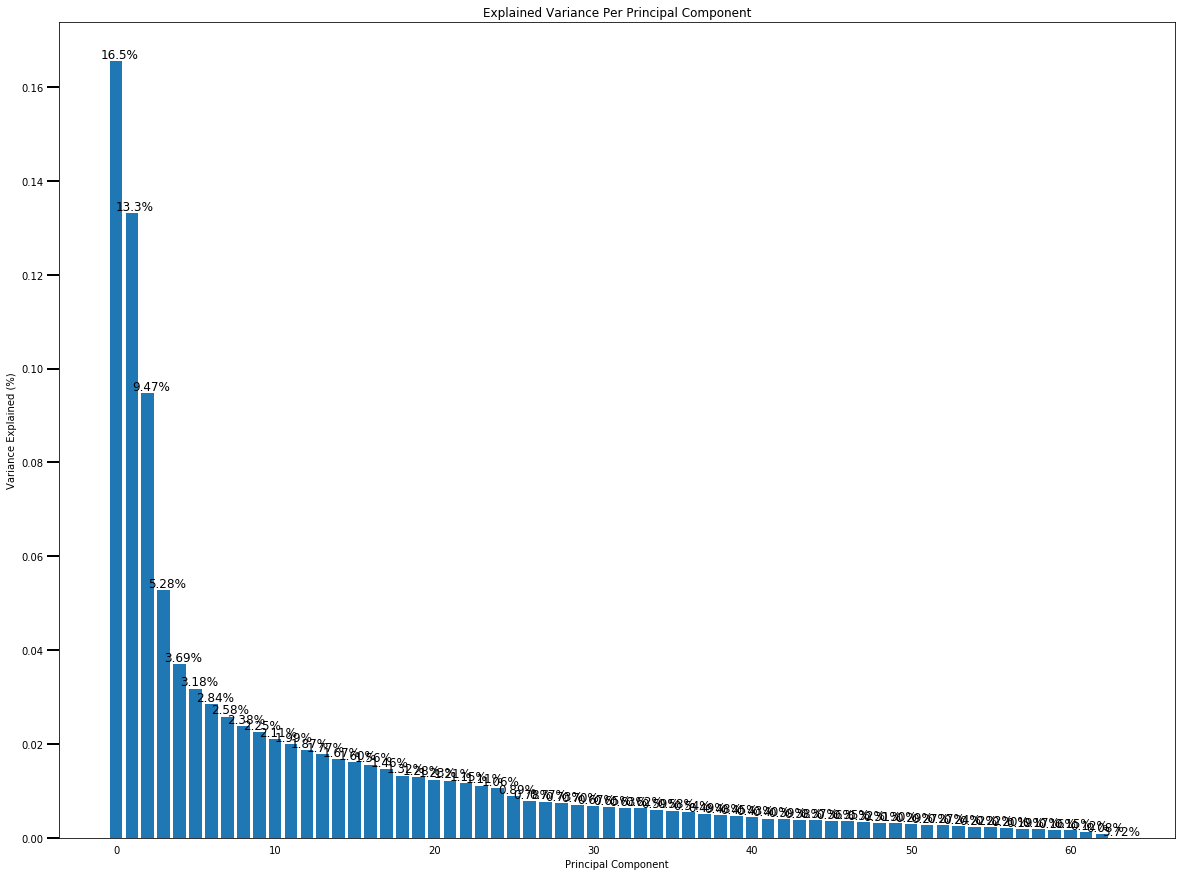

In [59]:
# Creates a larger sized plot to more easily see the curve of the cumalitve explained variance
# We can see the 
num_components=len(pca.explained_variance_ratio_)
ind = np.arange(num_components)
vals = pca.explained_variance_ratio_
 
plt.figure(figsize=(20, 15))
ax = plt.subplot(111)
ax.bar(ind, vals)
for i in range(num_components):
    ax.annotate(r"%s%%" % ((str(vals[i]*100)[:4])), (ind[i]+0.2, vals[i]), va="bottom", ha="center", fontsize=12)
    ax.xaxis.set_tick_params(width=0)
    ax.yaxis.set_tick_params(width=2, length=12)
 
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Explained (%)")
    plt.title('Explained Variance Per Principal Component')

We can see a decent decrease in explained variance from 24 to 25 so we will choose 25 as our 'magic' number (n_components=1 + wanted number of components)

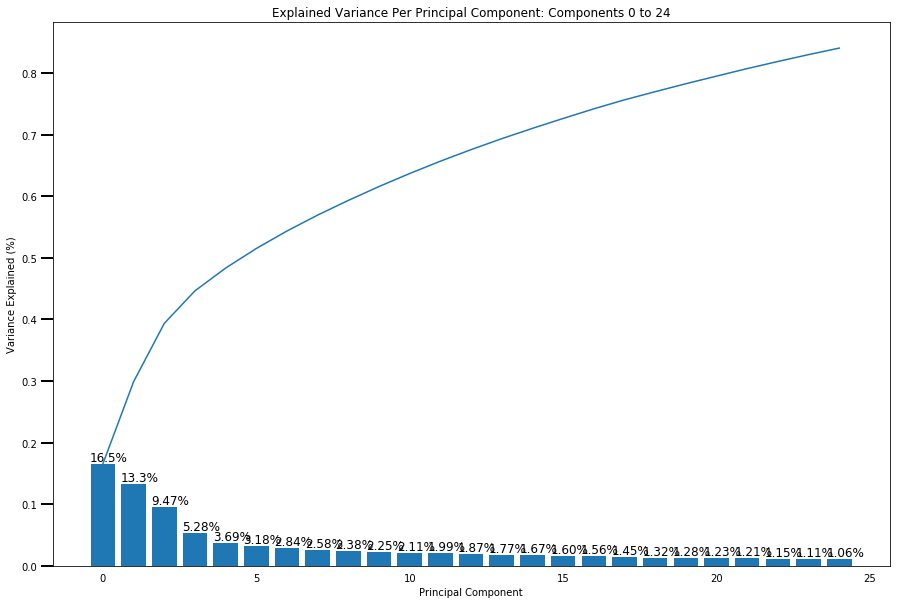

In [60]:
# Re-apply PCA to the data while selecting for number of components to retain.
pca = PCA(n_components=25)
gen_demo_pca_refined = pca.fit_transform(gen_demo_scaled)

num_components=len(pca.explained_variance_ratio_)
ind = np.arange(num_components)
vals = pca.explained_variance_ratio_
 
plt.figure(figsize=(15, 10))
ax = plt.subplot(111)
cumvals = np.cumsum(vals)
ax.bar(ind, vals)
ax.plot(ind, cumvals)
for i in range(num_components):
    ax.annotate(r"%s%%" % ((str(vals[i]*100)[:4])), (ind[i]+0.2, vals[i]), va="bottom", ha="center", fontsize=12)
    ax.xaxis.set_tick_params(width=0)
    ax.yaxis.set_tick_params(width=2, length=12)
 
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Explained (%)")
    plt.title('Explained Variance Per Principal Component: Components 0 to 24')

In [61]:
# Creates our finalized instance of PCA
final_pca = PCA(n_components=25)
gen_demo_pca_refined = final_pca.fit_transform(gen_demo_scaled)

### Discussion 2.2: Perform Dimensionality Reduction

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding dimensionality reduction. How many principal components / transformed features are you retaining for the next step of the analysis?)

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [62]:
# Creates our function for weight mapping
def weight_map(df, pca, n):
    '''
    INPUT:
    df: original dataframe
    pca: PCA instance
    n: the n-th principal component
    OUTPUT:
    A dictionary that begins with the component number
    and contains mapping for a column name to each weight
    '''
    comp_weights = pca.components_[n]
    feat_weightsmap = {}
    feat_weights = zip(df.columns, comp_weights)
    feat_weightsmap[f"Component {n+1}"] = sorted(
        feat_weights, key=lambda x: x[1], reverse=True)
    
    return(feat_weightsmap)

In [63]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.

weight_map(clean_gen_demo, pca, 0)

{'Component 1': [('PLZ8_ANTG3', 0.22534564946984101),
  ('PLZ8_ANTG4', 0.21688823715628991),
  ('CAMEO_INTL_2015_INCOME', 0.20464091894589898),
  ('HH_EINKOMMEN_SCORE', 0.20220715306030926),
  ('ORTSGR_KLS9', 0.19676846228905817),
  ('EWDICHTE', 0.19465643718883244),
  ('FINANZ_HAUSBAUER', 0.1595269133819624),
  ('KBA05_ANTG4', 0.15399210669288504),
  ('PLZ8_ANTG2', 0.1536849533228283),
  ('FINANZ_SPARER', 0.15308307058715992),
  ('ARBEIT', 0.14257078746858118),
  ('KBA05_ANTG3', 0.13672856897560576),
  ('ANZ_HAUSHALTE_AKTIV', 0.136059404579323),
  ('RELAT_AB', 0.13495364458106698),
  ('SEMIO_PFLICHT', 0.12114928377154745),
  ('SEMIO_REL', 0.11857763877951985),
  ('PRAEGENDE_JUGENDJAHRE_DECADE', 0.11223174430647499),
  ('SEMIO_RAT', 0.099559521123335146),
  ('SEMIO_TRADV', 0.09370412834135991),
  ('SEMIO_MAT', 0.082430180540676953),
  ('FINANZ_UNAUFFAELLIGER', 0.081067757344310487),
  ('SEMIO_FAM', 0.081002185118479009),
  ('SEMIO_KULT', 0.075513188923975377),
  ('FINANZ_ANLEGER', 0.07

In [64]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.

weight_map(clean_gen_demo, pca, 1)

{'Component 2': [('ALTERSKATEGORIE_GROB', 0.25627570448504611),
  ('SEMIO_ERL', 0.22992193713855522),
  ('FINANZ_VORSORGER', 0.22924751328109613),
  ('SEMIO_LUST', 0.1801176197869101),
  ('RETOURTYP_BK_S', 0.16189957366071606),
  ('FINANZ_HAUSBAUER', 0.12180911487479104),
  ('SEMIO_KRIT', 0.11786819272102159),
  ('SEMIO_KAEM', 0.11643658883156584),
  ('W_KEIT_KIND_HH', 0.11474619923467588),
  ('PLZ8_ANTG3', 0.098389693883751531),
  ('EWDICHTE', 0.097881978138245326),
  ('ORTSGR_KLS9', 0.09656262477619959),
  ('PLZ8_ANTG4', 0.096223055693820808),
  ('ANREDE_KZ', 0.093148035802504359),
  ('CAMEO_INTL_2015_INCOME', 0.079222609368445079),
  ('KBA05_ANTG4', 0.075217817153142755),
  ('SEMIO_DOM', 0.074494519062832817),
  ('ARBEIT', 0.071808698522017086),
  ('RELAT_AB', 0.069285166537496778),
  ('PLZ8_ANTG2', 0.068161364693253929),
  ('ANZ_HAUSHALTE_AKTIV', 0.066467986317138295),
  ('HH_EINKOMMEN_SCORE', 0.061935201505601931),
  ('FINANZ_MINIMALIST', 0.059389013749370875),
  ('WOHNDAUER_2008'

In [65]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.

weight_map(clean_gen_demo, pca, 2)

{'Component 3': [('SEMIO_VERT', 0.34466653894039551),
  ('SEMIO_SOZ', 0.26192442241694869),
  ('SEMIO_FAM', 0.24884336514264241),
  ('SEMIO_KULT', 0.23391749011009397),
  ('FINANZ_MINIMALIST', 0.1545026564587311),
  ('RETOURTYP_BK_S', 0.10900537397400623),
  ('FINANZ_VORSORGER', 0.10172417136413936),
  ('W_KEIT_KIND_HH', 0.0850996564870872),
  ('ALTERSKATEGORIE_GROB', 0.079645882065898871),
  ('SEMIO_REL', 0.067686799438005485),
  ('SEMIO_LUST', 0.064471557959160805),
  ('SEMIO_MAT', 0.055661599985341266),
  ('ORTSGR_KLS9', 0.050275771050670166),
  ('EWDICHTE', 0.049490179538172759),
  ('PLZ8_ANTG4', 0.049184259546559743),
  ('PLZ8_ANTG3', 0.048408200487663727),
  ('GREEN_AVANTGARDE', 0.04710412312983038),
  ('PRAEGENDE_JUGENDJAHRE_MOVEMENT', 0.04710412312983038),
  ('ARBEIT', 0.037347155079468827),
  ('RELAT_AB', 0.034352161299346907),
  ('PLZ8_ANTG2', 0.032671811057287281),
  ('WOHNDAUER_2008', 0.032635004149879666),
  ('CAMEO_INTL_2015_INCOME', 0.030190144913191008),
  ('KBA05_ANTG4

### Discussion 2.3: Interpret Principal Components

These scores can be interpreted as an absolute value to determine how much of an effect a feature has on the principal component, then the sign of the value can be interpreted which features increase together or inversely. For example, if feature has a high positive value (0.3) and another feature has a high negative value (-0.3), then as one increased the other decreases, and they both have a high impact on the principal component. Let's say we have another feature with a value of 0.05, then it would decrease as our negative value feature increases; however as it has a low absolute value, it does not affect the principal component much and changes less when other features change. One thing to note for these is that the SEMIO_ prefixed columns have a high weighting in the second and third components (either positively or negatively). PLZ8_ prefixed columns have a high weighting in the first component 

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [66]:
def find_kmean(k, data):
    '''
    INPUT: 
    k: Number of clusters to instantiate KMeans with
    data: Data to fit KMeans with and obtain a score with
    OUTPUT:
    score: The score of the KMeans model
    '''
    kmeans = KMeans(n_clusters=k)
    model = kmeans.fit(data)
    score = np.abs(model.score(data))
    score = np.abs(score)
    return score
    

In [67]:
# As it takes a very long time to check all clusters from 1 to 30, I would only run this to create a new state
scores=[]
cluster_vals=list(range(1, 31))
for val in cluster_vals:
    scores.append(find_kmean(val, gen_demo_pca_refined))

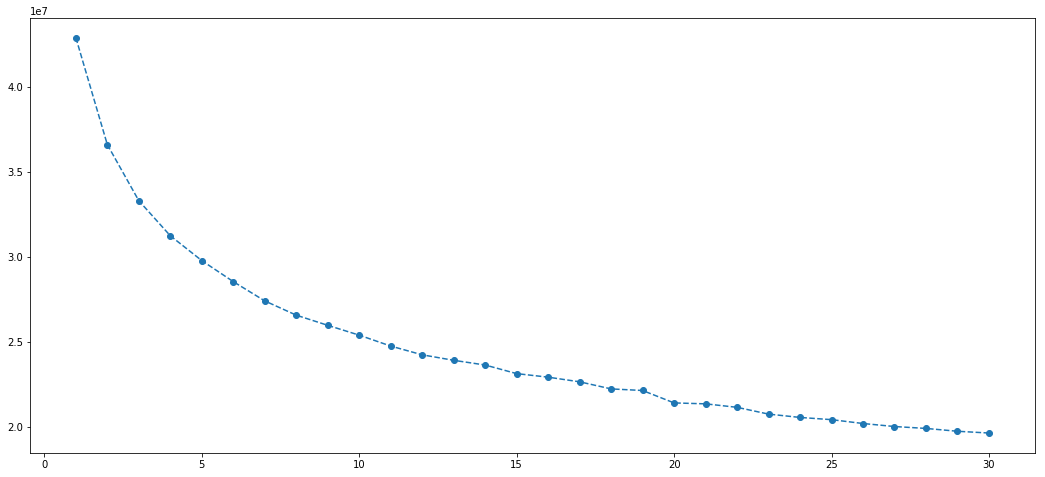

In [68]:
# Creates a large figure for our plot so we can more accurately choose an elbow from our array of scores
plt.figure(figsize=(18,8))
plt.plot(cluster_vals, scores, marker='o', linestyle='dashed')

It looks like there is an elbow at around cluster 14's score so we are going to choose 15 clusters to continue forward with

In [69]:
# Creates our final KMeans model and predict on our general demogrpahics
kmeans = KMeans(n_clusters=15)
final_model = kmeans.fit(gen_demo_pca_refined)
gen_demo_preds = final_model.predict(gen_demo_pca_refined)

### Discussion 3.1: Apply Clustering to General Population

It takes a very long time to check all the clusters' scores so I would not run the cell that obtains the list of scores unless you want to generate a new state. From this section we learned that our data will probably perform the best when using 15 centroids/clusters without sacrificing (too much) performance and computational time.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [70]:
# Load in the customer demographics data.
customers_demo = pd.read_csv('Udacity_CUSTOMERS_Subset.csv', sep=';')

In [72]:
# Runs the cleaning function on our data
clean_customers_demo = clean_data(customers_demo, feat_info)

In [73]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.
# Checks if the cleaned customers df has the same columns as the general demographics df
print(f'The cleaned cutomers df has the same columns as our general demo df: {clean_customers_demo.columns.all() == clean_gen_demo.columns.all()}') 

The cleaned cutomers df has the same columns as our general demo df: True


In [74]:
# Performs feature scaling, converts the scaled features back into a dataframe
# Then performs PCA transformation
clean_customers_scaled = scaler.transform(clean_customers_demo)
clean_customers_scaled = pd.DataFrame(clean_customers_scaled, clean_customers_demo.columns.tolist())
customers_demo_pca = final_pca.transform(clean_customers_scaled) 

In [75]:
# Obtains cluster predictions for our customer demographics 
customer_demo_preds = final_model.predict(customers_demo_pca) 

### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

Text(0.5,1,'General Demographic Clusters')

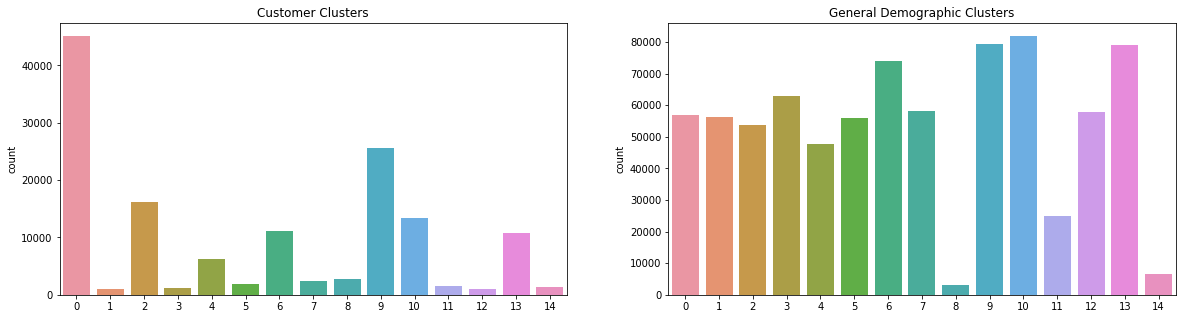

In [76]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,5))
sns.countplot(customer_demo_preds, ax=axes[0])
axes[0].set_title('Customer Clusters')
sns.countplot(gen_demo_preds, ax=axes[1])
axes[1].set_title('General Demographic Clusters')


Our largest cluster in our customers dataset  is cluster 0

In [77]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

center_0 = scaler.inverse_transform(final_pca.inverse_transform(final_model.cluster_centers_[0]))

In [79]:
pd.Series(center_0, clean_customers_demo.columns)

ALTERSKATEGORIE_GROB                 3.269872
ANREDE_KZ                            1.069906
FINANZ_MINIMALIST                    4.800244
FINANZ_SPARER                        1.636115
FINANZ_VORSORGER                     4.192118
FINANZ_ANLEGER                       1.514913
FINANZ_UNAUFFAELLIGER                2.182702
FINANZ_HAUSBAUER                     1.945496
GREEN_AVANTGARDE                     0.982278
HEALTH_TYP                           2.112765
RETOURTYP_BK_S                       4.011568
SEMIO_SOZ                            5.345389
SEMIO_FAM                            4.835926
SEMIO_REL                            3.740706
SEMIO_MAT                            3.797266
SEMIO_VERT                           6.207745
SEMIO_LUST                           5.362815
SEMIO_ERL                            4.145056
SEMIO_KULT                           4.859837
SEMIO_RAT                            2.689977
SEMIO_KRIT                           3.216246
SEMIO_DOM                         

Our smallest cluster in our customers dataset is cluster 4

In [80]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?
center_4 = scaler.inverse_transform(final_pca.inverse_transform(final_model.cluster_centers_[4]))

In [81]:
pd.Series(center_4, clean_gen_demo.columns)

ALTERSKATEGORIE_GROB                 3.401342
ANREDE_KZ                            1.565522
FINANZ_MINIMALIST                    2.547966
FINANZ_SPARER                        2.093177
FINANZ_VORSORGER                     4.110217
FINANZ_ANLEGER                       1.993261
FINANZ_UNAUFFAELLIGER                1.660777
FINANZ_HAUSBAUER                     4.283548
GREEN_AVANTGARDE                     0.041447
HEALTH_TYP                           2.271828
RETOURTYP_BK_S                       4.278457
SEMIO_SOZ                            4.059625
SEMIO_FAM                            3.662158
SEMIO_REL                            3.009425
SEMIO_MAT                            3.101902
SEMIO_VERT                           3.992380
SEMIO_LUST                           5.300224
SEMIO_ERL                            5.492842
SEMIO_KULT                           3.338969
SEMIO_RAT                            3.097959
SEMIO_KRIT                           4.966913
SEMIO_DOM                         

### Discussion 3.3: Compare Customer Data to Demographics Data


In our popular and unpopular centroids I found three columns that give a good idea of the customer demographics. "CAMEO_INTL_2015_INCOME" was the first column, in the overrepresented centroid it showed that the families are around the prosperous income level whereas in the underrepresented centroid it was arounf the less afluent income level. "CAMEO_INTL_2015_LIFE_STAGE" was the second column, it showed that the overrepresented was right between families with schoole age children and mature couples so we can assume this means families with older children whether almost out of school or just out of school. The underrepresented centroid showed that it is mostly families with young children. Finally the "MOBI_REGIO" shows the mobility of the people in the region, in our overrepresented centroid it shows there is low movement in their region whereas the underrepresented centroid showed that their movement was between high and very high (leaning more towards very high). From this we can build a simple demographic of the typical and attypical customer. To build a typical customer we take the traits from our overrepresentative centroid, so we have customers who are prosperous financially, are older couples that do not have children around (as often) and they live in a place that families do not typically move out of (communities of older, settled down, families). Then from our underrepresented centroid we can build an attypical customer (or opposing qualities of what our customers have). The attypical customer has a less afluent income, has a family with young children, and live in an area with high to very high mobility, small, less afluent, family housing which have changing tenants. It seems that our customers are older people who have more money they can spend on themselves rather as their children are not as dependent on them to make ends meet.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.